**SVM Classifier**

Equation of the hyper plane:

 $w \cdot x - b = 0$.

Decision boundary :

$\hat{y} = \text{sign}(w \cdot x - b)$


---


**Gradient Descent**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various ML models. It is used for updating the parameters of the learning model.

w = w - L*dw

b = b - L*db


---

**Learning rate:**

It is a tuning parameter that determines the size of step/leap when proceeding towards a minimum of a loss function.

In [124]:
#importing numpy library
import numpy as np

Importing the dependencies

In [125]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

#import SVM_classifier from SVM folder
from model import SVM_classifier

Data Collection and preprocessing

In [126]:
#Loading the data from csv file to pandas dataframe
diabetes_data = pd.read_csv('../SVM/dataset/diabetes.csv')

In [127]:
#print the first 5 rows
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [128]:
#number of rows and columns
diabetes_data.shape

(768, 9)

In [129]:
#To get statistical measures of data
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [130]:
diabetes_data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

0 ---> Non diabetic

1 ---> Diabetic

In [131]:
#Separating features and target
features = diabetes_data.drop('Outcome', axis=1)
target = diabetes_data['Outcome']

In [132]:
print(features)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [133]:
print(target)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [134]:
#check if there are null values
diabetes_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

**Data Standardization**

.fit() --> calculates mean and standard deviation

.transform() --> fits the data according to calculated mean and standard deviation

>*Centering* - subtract the mean from value x

>*Scaling* - dividing the x value by std


---


**Train test split**

>Split the data into training and testing set

>The Scaler will be fitted to training data only, and the calculated measures will be applied to testing features for centering and scaling, to ensure real world scenarios

In [135]:
#Create an instance of StandardScaler
scaler = StandardScaler()

In [136]:
#Split the data into training and testing data before fitting the scaler
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size=0.2, stratify=target, random_state=2)

In [137]:
#Fit the scaler only on training set
scaler.fit(X_train)

StandardScaler()

In [138]:
#Transform the training data and testing data using scaler fitted on training data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [139]:
#Printing standardized training data
print(X_train)

[[-1.13796489 -0.07971099 -3.5556072  ...  0.02825037 -0.98159708
  -0.7885233 ]
 [ 0.64067858 -0.52091877  0.02549599 ... -0.17184452 -1.03823795
   0.31879426]
 [-0.84152431  2.12632792 -0.48609018 ... -0.25938604 -0.21545477
   2.19271628]
 ...
 [ 2.12288146 -1.15121561  0.23013046 ... -0.25938604 -0.50760242
   0.14843771]
 [ 0.04779742 -0.30031488  0.43476492 ...  0.90366551 -0.69839272
   0.40397253]
 [-1.13796489 -1.11970076 -0.07682125 ...  0.45345201 -0.69243053
  -0.70334503]]


In [140]:
#80% data goes to training, 20% for testing
print(features.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


**SMOTE** : Synthetic Minority Oversampling Technique

- Record of diabetic patients is low, so have to generate new data points 

- SMOTE does not just copy data. It selects an existing minority class instance (a Diabetic patient), finds its nearest neighbors in that 8-dimensional feature space, and creates new, synthetic instances mathematically placed along the line segments connecting them.

> *Precautions* : Data Leakage

- You must split your data FIRST, and ONLY oversample the training set (X_train, Y_train).

- If you apply SMOTE to your entire dataset before running train_test_split, synthetic data derived from your test set will end up in your training set. Your model will be tested on data it essentially already saw.

- Your accuracy will artificially shoot up to 95%+, and the model will be a complete lie. Your test set must strictly remain real, untouched data.


In [141]:
# 1. Initialize SMOTE
# Using a random_state ensures reproducibility 
smote = SMOTE(random_state=2)

In [142]:
# 2. Generate synthetic data strictly on the training set
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)

In [143]:
# 3. Verify the class balance has been fixed
print("Before SMOTE:")
print(Y_train.value_counts())

Before SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64


In [144]:
print("\nAfter SMOTE:")
# Y_train_resampled might be a numpy array depending on the pandas version, 
# converting to Series just to safely use value_counts()
print(pd.Series(Y_train_resampled).value_counts())


After SMOTE:
Outcome
1    400
0    400
Name: count, dtype: int64


**Training the model**

In [145]:
classifier = SVM_classifier(learning_rate=0.001, epochs=1000, lambda_parameter=0.01)

In [146]:
#Training the SVM classifier with training data
classifier.fit(X_train_resampled, Y_train_resampled)

**Model Evaluation**


---



Predict the outcome for training data

In [147]:
#accuracy on training data
X_train_prediction = classifier.predict(X_train)

Calculate the accuracy of the predicted labels against original outcome using *accuracy_score*

**Note : This accuracy is calculated for training data (Y_train)**

In [148]:
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

In [149]:
#Print the accuracy score on training data
print('Accuracy score on training data: ', training_data_accuracy)

Accuracy score on training data:  0.7687296416938111




---


Calculating the accuracy against test data

In [150]:
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

In [151]:
print('Accuracy score on test data: ', test_data_accuracy)

Accuracy score on test data:  0.7337662337662337


Building a Predictive system

In [152]:
input_data = (5,166,72,19,175,25.8,0.587,51)

#Change the input data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

#standardize the input data
std_data = scaler.transform(pd.DataFrame(input_data_reshaped, columns=features.columns))
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if prediction[0] == 0:
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[ 0.344238    1.40148656  0.12781322 -0.10834817  0.77530224 -0.79714106
   0.34797285  1.51129009]]
[1]
The person is diabetic


In [153]:
# Generate the confusion matrix for the test data
cm = confusion_matrix(Y_test, X_test_prediction)

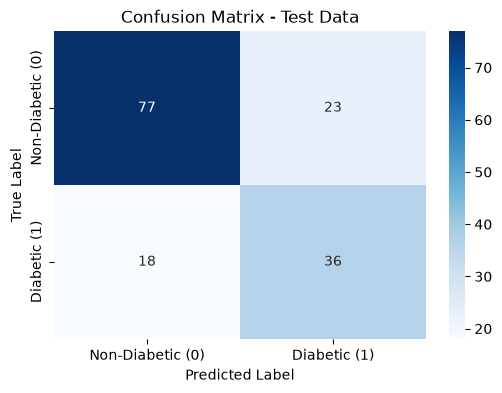

In [154]:
# Visualize it using Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Diabetic (0)', 'Diabetic (1)'], 
            yticklabels=['Non-Diabetic (0)', 'Diabetic (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Data')
plt.show()